<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/-week7-/blob/main/mplementaci%C3%B3n_de_un_Modelo_Popular_de_CNN_en_TensorFlow_%2B_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando entrenamiento...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 48ms/step - accuracy: 0.4643 - loss: 1.4713 - val_accuracy: 0.5694 - val_loss: 1.2172
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.6135 - loss: 1.0989 - val_accuracy: 0.6394 - val_loss: 1.0191
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6710 - loss: 0.9470 - val_accuracy: 0.6610 - val_loss: 0.9850
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.7046 - loss: 0.8410 - val_accuracy: 0.6875 - val_loss: 0.8945
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7316 - loss: 0.7658 - val_accuracy: 0.6968 - val_loss: 0.9161
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.7546 - loss: 0.7021 - val_accuracy: 0.7174 - val_loss: 0.8387
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.7720 - loss: 0.6479 - val_accuracy: 0.7097 - val_loss: 0.8494
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45m

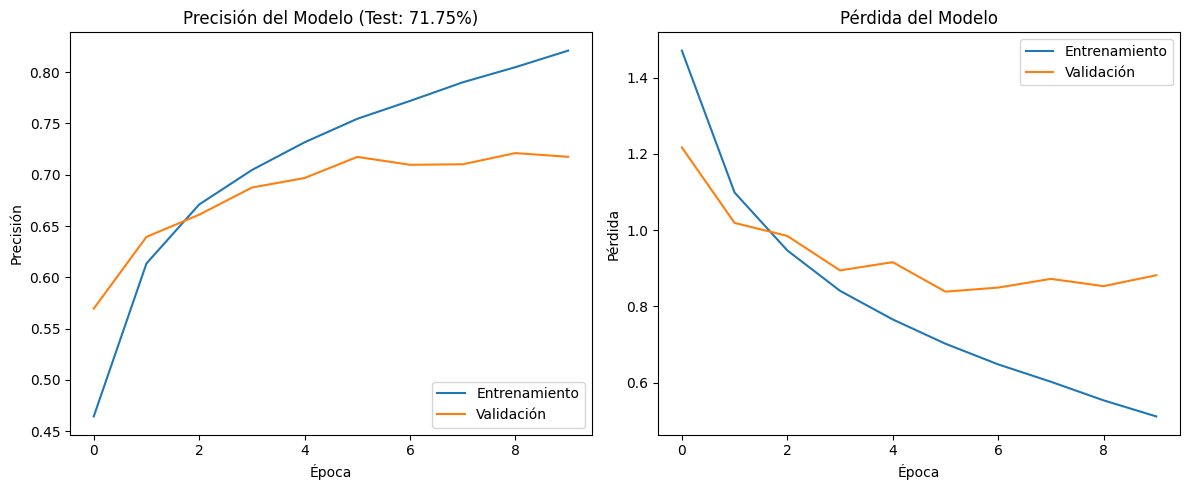

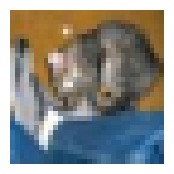

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Predicción: gato | Clase Real: gato


In [4]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CARGA Y PREPROCESAMIENTO ---
# Descarga del dataset CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalización de valores de píxeles entre 0 y 1
train_images, test_images = train_images / 255.0, test_images / 255.0

class_names = ['avión', 'automóvil', 'pájaro', 'gato', 'venado',
               'perro', 'rana', 'caballo', 'barco', 'camión']

# --- 2. DEFINICIÓN DE LA ARQUITECTURA ---
model = models.Sequential([
    # Capas Convolucionales para extraer características
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Capas Densas para clasificación final
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)
])

# --- 3. COMPILACIÓN Y ENTRENAMIENTO ---
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Inicio del entrenamiento (10 épocas para evidencia rápida)
print("Iniciando entrenamiento...")
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

# --- 4. EVALUACIÓN Y GRÁFICAS ---
print("\nEvaluación final:")
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

# Creación de gráficas de rendimiento
plt.figure(figsize=(12, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title(f'Precisión del Modelo (Test: {test_acc:.2%})')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend(loc='lower right')

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# --- 5. PREDICCIÓN DE MUESTRA ---
# Visualización de una predicción real del modelo entrenado
plt.figure(figsize=(2,2))
plt.imshow(test_images[0])
plt.axis('off')
plt.show()

prediction = model.predict(np.expand_dims(test_images[0], axis=0))
clase_predicha = class_names[np.argmax(prediction)]
clase_real = class_names[test_labels[0][0]]
print(f"Predicción: {clase_predicha} | Clase Real: {clase_real}")

 segunda configuración asociada a Transfer Learning

In [5]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

# 1. CARGA DE DATOS (Mismo pipeline anterior)
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
train_images, test_images = train_images / 255.0, test_images / 255.0

# 2. CARGA DEL MODELO PRE-ENTRENADO (Base)
# Se excluye la capa superior original (top) para usar una propia
base_model = tf.keras.applications.MobileNetV2(input_shape=(32, 32, 3),
                                               include_top=False,
                                               weights='imagenet')

# CONGELACIÓN:
base_model.trainable = False

# 3. CONSTRUCCIÓN DEL MODELO FINAL
model_tl = models.Sequential([
    base_model,                 # La base experta (MobileNetV2)
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10)            # Salida para las 10 clases de CIFAR-10
])

# 4. COMPILACIÓN Y ENTRENAMIENTO
model_tl.compile(optimizer='adam',
                 loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                 metrics=['accuracy'])

# El entrenamiento será más rápido pues solo se ajustan las últimas capas
history_tl = model_tl.fit(train_images, train_labels, epochs=5,
                          validation_data=(test_images, test_labels))

/tmp/ipykernel_5475/64120569.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=(32, 32, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.2958 - loss: 1.9506 - val_accuracy: 0.3164 - val_loss: 1.8788
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.3281 - loss: 1.8524 - val_accuracy: 0.3313 - val_loss: 1.8484
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.3398 - loss: 1.8189 - val_accuracy: 0.3344 - val_loss: 1.8342
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.3485 - loss: 1.7944 - val_accuracy: 0.3423 - val_loss: 1.8240
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.3555 - loss: 1.7753 - val_accuracy: 0.3425 - val_loss: 1.8149
